In [2]:
library("DESeq2")
library("WGCNA")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



In [3]:
# Load the counts and the metadata
rna_counts <- read.table("rna_counts.txt", header = TRUE, row.names = 1, sep="\t")
mirna_counts <- read.table("mirna_counts.txt", header = TRUE, row.names = 1, sep="\t")
metadata <- read.table("all_metadata.csv", header = TRUE, row.names = 1, sep=",")


In [4]:
head(rna_counts)

,SRR5580910,SRR5580911,SRR5580912,SRR5580913,SRR5580914,SRR5580915,SRR5580916,SRR5580917,SRR5580920,SRR5580921,⋯,SRR5581285,SRR5581286,SRR5581287,SRR5581289,SRR5581300,SRR5581301,SRR5581322,SRR5581323,SRR5581324,SRR5581325
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F29,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F16,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SAMD11,41,34,59,35,91,99,190,165,77,28,⋯,44,123,76,89,101,75,332,344,39,42
NOC2L,991,2129,1589,5432,1306,3579,3000,2476,3535,3937,⋯,1665,2683,1337,1800,4473,3195,2372,4831,1308,5125
KLHL17,57,54,68,117,59,162,236,198,142,182,⋯,81,196,57,78,372,118,59,283,63,353


In [5]:
head(mirna_counts)

,SRR5580918,SRR5580919,SRR5580922,SRR5580923,SRR5580924,SRR5580925,SRR5580928,SRR5580929,SRR5580930,SRR5580931,⋯,SRR5581312,SRR5581313,SRR5581314,SRR5581315,SRR5581316,SRR5581317,SRR5581318,SRR5581319,SRR5581320,SRR5581321
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
hsa-miR-6859-5p,1,3,1,0,0,2,1,0,0,1,⋯,1,3,1,0,3,0,2,3,3,0
hsa-miR-6859-3p,0,0,0,0,0,0,0,0,0,1,⋯,0,1,0,0,0,2,0,2,0,0
hsa-miR-1302,0,0,1,0,0,1,0,0,0,0,⋯,1,0,2,0,1,0,0,3,0,0
hsa-miR-12136,316,168,132,162,172,542,188,239,229,532,⋯,533,296,367,810,206,410,253,702,189,170
hsa-miR-200b-5p,771,1163,751,602,621,675,654,1214,839,1404,⋯,2671,2397,1108,804,1236,923,1641,2049,1226,1546
hsa-miR-200b-3p,100767,150977,114506,110369,86542,88244,72407,151519,93304,146978,⋯,318201,315877,135063,85776,143547,95660,187811,221405,150175,175194


In [6]:
head(metadata)

,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,Center.Name,⋯,PHENOTYPE,Platform,RACE,ReleaseDate,create_date,version,Sample.Name,sex,SRA.Study,tissue
,<int>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
SRR5580910,53,RNA-Seq,260,8678680221,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140646,Human,3306606952,CHANG GUNG UNIVERSITY,⋯,adjacent normal,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:10:00Z,1,CRC_078-N,male,SRP107326,rectum
SRR5580911,53,RNA-Seq,263,8186874340,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140647,Human,3140298478,CHANG GUNG UNIVERSITY,⋯,neoplastic,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:11:00Z,1,CRC_078-T,male,SRP107326,rectum
SRR5580912,48,RNA-Seq,279,14643046897,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140644,Human,6095216605,CHANG GUNG UNIVERSITY,⋯,adjacent normal,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:15:00Z,1,CRC_076-N,male,SRP107326,rectum
SRR5580913,48,RNA-Seq,278,12679355033,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140645,Human,5226996823,CHANG GUNG UNIVERSITY,⋯,neoplastic,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:14:00Z,1,CRC_076-T,male,SRP107326,rectum
SRR5580914,67,RNA-Seq,265,13271208180,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140650,Human,5605039330,CHANG GUNG UNIVERSITY,⋯,adjacent normal,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:11:00Z,1,CRC_089-N,male,SRP107326,rectum
SRR5580915,67,RNA-Seq,264,8519762268,"Wen-Sy Tsai\, Chang Gung Memorial Hospital\, Tawain",PRJNA387172,SAMN07140651,Human,3524246692,CHANG GUNG UNIVERSITY,⋯,neoplastic,ILLUMINA,Mongoloid,2020-05-31T00:00:00Z,2017-05-21T02:03:00Z,1,CRC_089-T,male,SRP107326,rectum


In [7]:
head(rna_counts)

,SRR5580910,SRR5580911,SRR5580912,SRR5580913,SRR5580914,SRR5580915,SRR5580916,SRR5580917,SRR5580920,SRR5580921,⋯,SRR5581285,SRR5581286,SRR5581287,SRR5581289,SRR5581300,SRR5581301,SRR5581322,SRR5581323,SRR5581324,SRR5581325
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
OR4F5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F29,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F16,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
SAMD11,41,34,59,35,91,99,190,165,77,28,⋯,44,123,76,89,101,75,332,344,39,42
NOC2L,991,2129,1589,5432,1306,3579,3000,2476,3535,3937,⋯,1665,2683,1337,1800,4473,3195,2372,4831,1308,5125
KLHL17,57,54,68,117,59,162,236,198,142,182,⋯,81,196,57,78,372,118,59,283,63,353


In [8]:
colnames(metadata)

[1] "age"                  "Assay.Type"           "AvgSpotLen"          
 [4] "Bases"                "BIOMATERIAL_PROVIDER" "BioProject"          
 [7] "BioSample"            "BioSampleModel"       "Bytes"               
[10] "Center.Name"          "Consent"              "DATASTORE.filetype"  
[13] "DATASTORE.provider"   "DATASTORE.region"     "disease"             
[16] "disease_stage"        "ETHNICITY"            "Experiment"          
[19] "Instrument"           "isolate"              "Library.Name"        
[22] "LibraryLayout"        "LibrarySelection"     "LibrarySource"       
[25] "Organism"             "PHENOTYPE"            "Platform"            
[28] "RACE"                 "ReleaseDate"          "create_date"         
[31] "version"              "Sample.Name"          "sex"                 
[34] "SRA.Study"            "tissue"

In [9]:
# change column names of rna counts with the isolate from the metadata that has the same row name
#colnames(rna_counts) <- metadata[colnames(rna_counts), "Sample.Name"]
# same for mirna counts
#colnames(mirna_counts) <- metadata[colnames(mirna_counts), "Sample.Name"]

In [10]:
#head(rna_counts)

In [11]:
#head(mirna_counts)

In [12]:
#colnames(rna_counts)

In [13]:
# merge dna and mirna counts based on column names
#merged_counts <- merge(rna_counts, mirna_counts, by = "row.names", all = TRUE)
#rownames(merged_counts) <- merged_counts$Row.names
#merged_counts$Row.names <- NULL

In [14]:
#head(merged_counts)

In [15]:
#colnames(merged_counts)

In [16]:
# get the metadata for the samples in rna counts
rna_metadata <- metadata[colnames(rna_counts), ]
# reorder the rna metadata to match the order of the rna counts
rna_metadata <- rna_metadata[match(colnames(rna_counts), rownames(rna_metadata)), ]

In [17]:
# make the differential expression with DESeq2
dds <- DESeqDataSetFromMatrix(countData = rna_counts,
                              colData = rna_metadata,
                              design = ~ PHENOTYPE)
dds <- DESeq(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

In [18]:
res = results(dds, contrast = c("PHENOTYPE", "adjacent normal", "neoplastic"))
res = res[order(res$padj), ]

In [19]:
# show results for SALL2 only
sall2_res <- res[rownames(res) == "SALL2", ]
print(sall2_res)

log2 fold change (MLE): PHENOTYPE adjacent normal vs neoplastic 
Wald test p-value: PHENOTYPE adjacent normal vs neoplastic 
DataFrame with 1 row and 6 columns
       baseMean log2FoldChange     lfcSE      stat      pvalue        padj
      <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
SALL2   42.9243       0.565647  0.118171   4.78666 1.69576e-06 2.85809e-06


In [20]:
# delete rows with NA in the padj column
res <- res[!is.na(res$padj), ]
dim(res)

[1] 19197     6

In [21]:
res_ordered <- res[order(res$padj), ]
df = res_ordered
df$Category <- "Not significant" # UMBRALES PUEDEN VARIAR!
df[which(df$log2FoldChange >= 2 & df$padj <= 0.05),]$Category <- "Up-regulated"
df[which(df$log2FoldChange <= -2 & df$padj <= 0.05),]$Category <- "Down-regulated"

In [22]:
table(df$Category)


 Down-regulated Not significant    Up-regulated 
           1030           17579             588 

In [23]:
# get only those that are up or down regulated
df_sig <- df[df$Category != "Not significant", ]
dim(df_sig)

[1] 1618    7

In [24]:
# Create WGCNA network with significant genes
# Select only the significant genes
sig_genes <- rownames(df_sig)

In [25]:
# Obtain DESeq2 normalized counts for significant genes
norm_counts <- counts(dds, normalized = TRUE)[sig_genes, ]

In [27]:
# create a WGCNA object
# Transpose the normalized counts matrix
datExpr0 <- t(norm_counts)
gsg <- goodSamplesGenes(datExpr0, verbose = 3)
if (!gsg$allOK) {
  datExpr0 <- datExpr0[gsg$goodSamples, gsg$goodGenes]
}

 Flagging genes and samples with too many missing values...
  ..step 1


pickSoftThreshold: will use block size 1618.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1618 of 1618


Warning message:
“executing %dopar% sequentially: no parallel backend registered”


   Power SFT.R.sq  slope truncated.R.sq mean.k. median.k. max.k.
1      1    0.267  0.377          0.745 436.000  443.0000  774.0
2      2    0.656 -0.599          0.813 174.000  155.0000  448.0
3      3    0.870 -0.913          0.936  84.600   61.5000  291.0
4      4    0.908 -1.060          0.968  46.700   27.6000  204.0
5      5    0.919 -1.170          0.972  28.100   13.3000  151.0
6      6    0.905 -1.260          0.951  18.100    7.5600  116.0
7      7    0.881 -1.330          0.930  12.300    4.4500   91.2
8      8    0.848 -1.410          0.901   8.670    2.6500   73.5
9      9    0.865 -1.400          0.909   6.340    1.6900   60.3
10    10    0.882 -1.390          0.924   4.780    1.0900   50.2
11    11    0.895 -1.400          0.927   3.680    0.7200   42.3
12    12    0.897 -1.390          0.924   2.900    0.4940   36.1
13    13    0.860 -1.440          0.905   2.330    0.3560   31.1
14    14    0.868 -1.440          0.912   1.900    0.2530   26.9
15    15    0.874 -1.420 

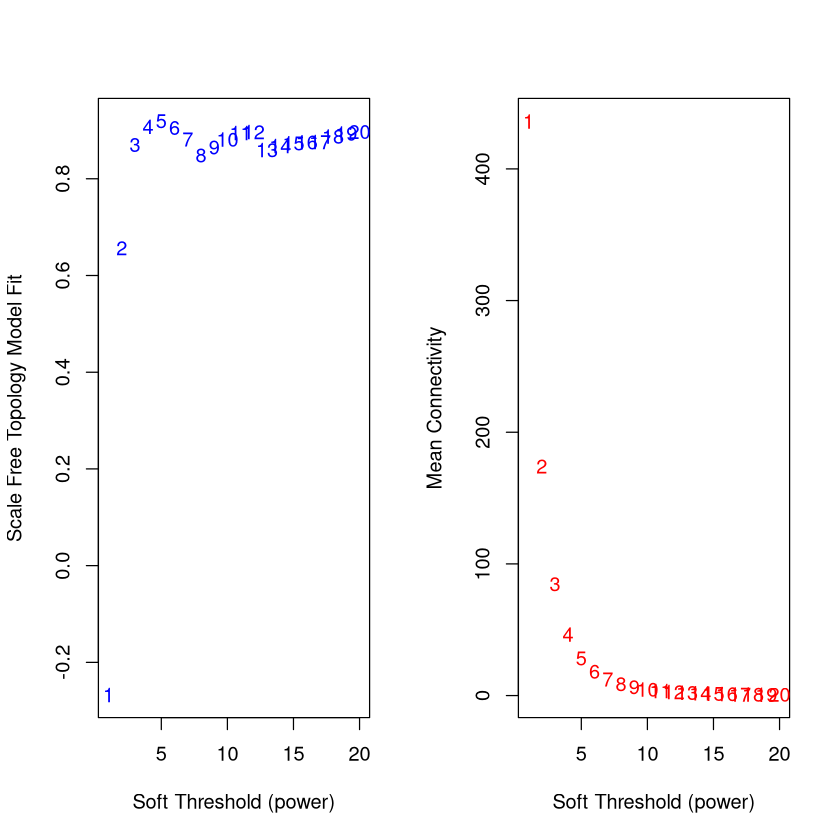

In [28]:
powers <- c(1:20)
sft <- pickSoftThreshold(datExpr0, powerVector = powers, verbose = 5)

# Plot scale independence and mean connectivity
par(mfrow = c(1,2))
plot(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2],
     xlab="Soft Threshold (power)", ylab="Scale Free Topology Model Fit", type="n")
text(sft$fitIndices[,1], -sign(sft$fitIndices[,3])*sft$fitIndices[,2], labels=powers, col="blue")

plot(sft$fitIndices[,1], sft$fitIndices[,5],
     xlab="Soft Threshold (power)", ylab="Mean Connectivity", type="n")
text(sft$fitIndices[,1], sft$fitIndices[,5], labels=powers, col="red")


In [29]:
net <- blockwiseModules(
  datExpr0,
  power = 12,                 # replace with chosen power
  TOMType = "signed",
  minModuleSize = 30,
  reassignThreshold = 0,
  mergeCutHeight = 0.25,
  numericLabels = TRUE,
  pamRespectsDendro = FALSE,
  verbose = 3
)


 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 4 genes from module 8 because their KME is too low.
 ..merging modules that are too close..
     mergeCloseModules: Merging modules whose distance is less than 0.25
       Calculating new MEs...


moduleColors
     blue     brown     green      grey       red turquoise    yellow 
      101        82        43       774        34       523        61 

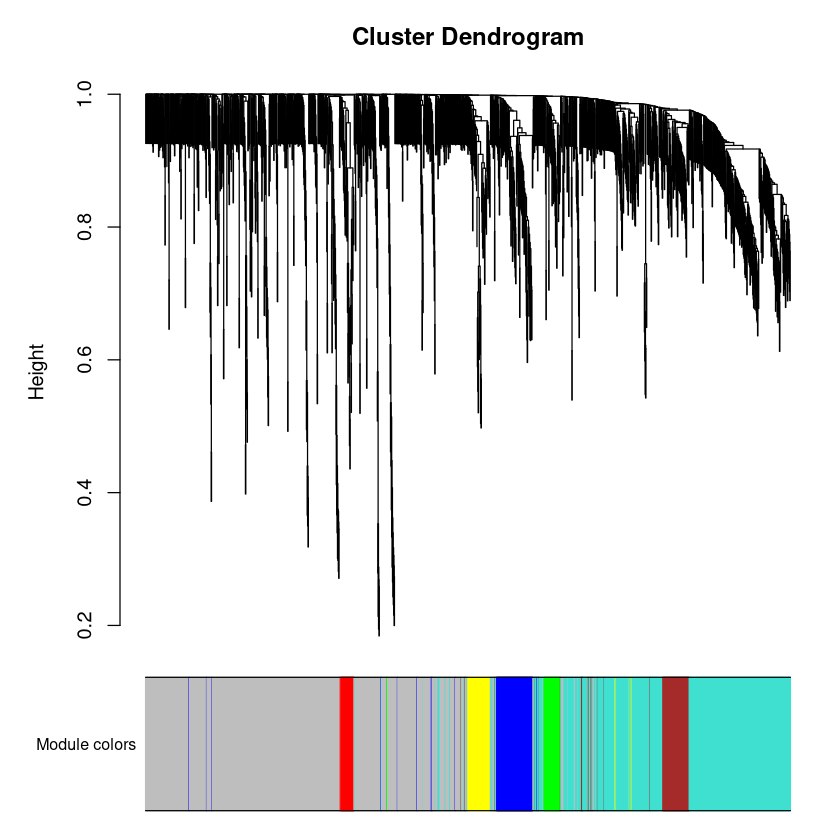

In [30]:
moduleColors <- labels2colors(net$colors)
table(moduleColors)
plotDendroAndColors(net$dendrograms[[1]], moduleColors[net$blockGenes[[1]]],
                    "Module colors", dendroLabels = FALSE)


In [32]:
# Ensure rownames of metadata match SRR column names
rownames(rna_metadata) <- rownames(rna_metadata)

# Subset to match your WGCNA data (after transposing)
sample_ids <- rownames(datExpr0)

# Extract trait (e.g., Tumor vs Normal)
trait_vector <- metadata[sample_ids, "PHENOTYPE"]

# One-hot encode it (if needed)
traitData <- data.frame(
  Tumor  = ifelse(trait_vector == "neoplastic", 1, 0),
  Normal = ifelse(trait_vector == "adjacent normal", 1, 0)
)

rownames(traitData) <- sample_ids


In [33]:
MEs <- net$MEs
moduleTraitCor <- cor(MEs, traitData, use = "p")
moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples = nrow(datExpr0))

In [36]:
# Converts the column names (e.g., ME1, ME2) to actual color names
moduleNames <- substring(names(MEs), 3)  # Removes the "ME" prefix


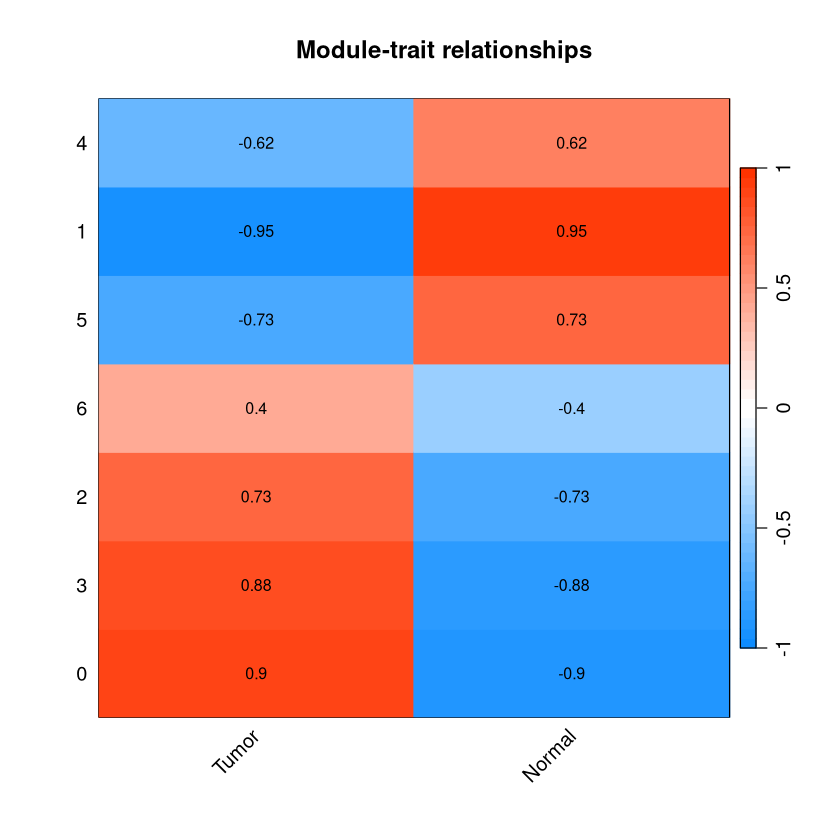

In [37]:
labeledHeatmap(Matrix = moduleTraitCor,
               xLabels = colnames(traitData),
               yLabels = moduleNames,
               ySymbols = moduleNames,
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = signif(moduleTraitCor, 2),
               setStdMargins = FALSE,
               cex.text = 0.8,
               zlim = c(-1,1),
               main = "Module-trait relationships")


In [38]:
# differential expresssion with miRNAs
# subset the metadata to match the miRNA counts
mirna_metadata <- metadata[colnames(mirna_counts), ]
# reorder the mirna metadata to match the order of the mirna counts
mirna_metadata <- mirna_metadata[match(colnames(mirna_counts), rownames(mirna_metadata)), ]
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_counts,
                                     colData = mirna_metadata,
                                     design = ~ PHENOTYPE)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [56]:
dds_mirna <- DESeq(dds_mirna)
res_mirna = results(dds_mirna, contrast = c("PHENOTYPE", "adjacent normal", "neoplastic"))
res_mirna = res_mirna[order(res_mirna$padj), ]

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

-- replacing outliers and refitting for 55 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions


In [57]:
res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # UMBRALES PUEDEN VARIAR!
df_mirna[which(df_mirna$log2FoldChange >= 0.5 & df_mirna$padj <= 0.05),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange <= -0.5 & df_mirna$padj <= 0.05),]$Category <- "Down-regulated"

In [58]:
df_mirna_sig <- df_mirna[df_mirna$Category != "Not significant", ]

In [59]:
# get the normalized counts for the significant miRNAs
norm_counts_mirna <- counts(dds_mirna, normalized = TRUE)[rownames(df_mirna_sig), ]

In [ ]:
# correlate miRNAs with module eigengenes
miRNA_t = t(norm_counts_mirna)